# 535 — Sports Tier 1 mechanism notebook

**Conductor:** `530_sports_pipeline.ipynb` builds the base panel; this notebook extends **Tier 1** (VECTOR / SCOUT): separate **pool quality** $Q$, **congestion** $C$, **opportunity** $O$, and **draft** $Y$, then exploratory specs toward the inverted-U.

**Run order (refer to CELL names, not indices):** **EDIT BLANK** (session log) → **CELL 0** (config + `RUN_CELL*`) → **CELL 1** → **CELL 2** → **CELL 3** → **CELL 4**. Each numbered CELL is a **markdown header** immediately followed by a **code** cell whose first line is `# CELL N — …`, matching the header (same pattern as `530_sports_pipeline.ipynb`; **CELL 0** switchboard follows `540_tenure_pipeline.ipynb`).

**Theory / memos (repo):**
- `sports/documents/tier_1_roadmap.md` — **living checklist:** pipeline steps, `df` column contract, CELL 0 knobs (edit with the project).
- `1-Various_PDE_and_Chat_stuff/5-Manuscript/Vector_to_Scout_Tier1_Modeling_Direction.md`
- `1-Various_PDE_and_Chat_stuff/5-Manuscript/tier_1_model.md`
- `1-Various_PDE_and_Chat_stuff/5-Manuscript/2026_0430_Paper7_feedback.md` (theory vs minimal model; distinction scarcity)

**Data:** `datasets/mbb/player_season_panel_530.csv` at **workspace root** (same layout as `530_sports_pipeline.ipynb`) via `sports_pipeline.paths.panel_530_csv()`.

### EDIT BLANK · session log

Burn cell for `.cursor/rules` diff sync. **Next code cell** repeats the same name in its first comment line. Not a numbered CELL.


In [4]:
# EDIT BLANK — session log
##### EDIT BLANK ###### DISCARD
# session: 2026-05-06 — CELL 0: CELL4_EDA_PLOT_STYLE poolq_line | bins_bars_520 (530 ventile_eda_plot_style).
# session: 2026-05-06 — 535 CFG: 8 equal_width bins (poolqeqwidth) + ppm to match 530 bar exports.
# session: 2026-05-06 — CELL 4: Tier 1 EDA (binned draft, LPM, PDP-style Q grid).
# session: 2026-05-06 — paths.project_root = workspace root (datasets/mbb matches 530).
# session: 2026-05-05 — tier_1_roadmap → sports/documents; title cell path sync.
# session: 2026-03-31 — Add sports/tier_1_roadmap.md + title link.
# session: 2026-03-31 — Restore CELL 3 / CELL 0 comments (min_minutes, PRIMARY_POOL_MODE, tier1 notes).
# session: 2026-03-31 — CELL 0 md+code (config, RUN_CELL*); wrap CELL 1–3; 540-style switchboard.
# session: 2026-03-31 — 535: CELL 1–3 md/code pairs complete; roadmap refreshed; title run-order blurb.
# session: 2026-05-04 — 535: CELL headers + md/code pairs (match 530 naming).
# session: 2026-05-04 — Resync: follow .cursor/rules — blank edit first; use EditNotebook for cell content (not MCP notebook_edit_cell / bulk_add for substantive cells).
# session: 2026-03-31 — Initial 535 scaffold (rename 545→535; burn cell for diff sync).


### CELL 0 — Config · `RUN_CELL*` flags · analysis knobs

Central switchboard (same role as **`540_tenure_pipeline.ipynb`** CELL 0): which stages run, plus Tier 1 / panel options consumed by **CELL 1–4**. Re-run this code cell after changing any flag or knob.


In [5]:
# CELL 0 — Config · RUN_CELL* flags · analysis knobs

# --- Run gates (edit here only; re-run CELL 0 after changes) ---
RUN_CELL1 = True  # Environment · imports · panel path
RUN_CELL2 = True  # Load panel · PPM · legacy poolq_loo
RUN_CELL3 = True  # Tier 1 mechanism variables
RUN_CELL4 = True  # Tier 1 EDA (binned draft vs Q, LPM, PDP-style Q grid)

# --- Panel / Tier 1 knobs (read by CELL 2–4) ---

# Align with 530 CELL 2 for the run you care about (e.g. PPM + z-score for poolqeqwidth bar charts).
PERF_METRIC = "ppm"

# True → CELL 4 bins poolq_loo + filter_panel(CFG) using CFG.ventiles / CFG.poolq_binning (same as 530).
# False → CELL 4 uses PRIMARY_POOL_MODE Tier 1 pool column (congestion_quality / congestion_crowding).
CELL4_MATCH_530_VENTILE = True

# Left EDA panel (mirrors 530 PipelineConfig.ventile_eda_plot_style):
#   "poolq_line" — line vs mean Q in bin; "bins_bars_520" — bars vs ventile index 1..K (1 = lowest poolq).
CELL4_EDA_PLOT_STYLE = "bins_bars_520"

# min_minutes=None keeps full sample; set e.g. 50.0 later to match analysis filters.
# TODO: align with PipelineConfig.min_minutes when you want a single source of truth.
MIN_MINUTES_TIER1 = None

# Toggle for Tier 1 EDA when CELL4_MATCH_530_VENTILE is False: "quality" / "crowding" (tier1_primary_pool_column).
PRIMARY_POOL_MODE = "quality"

# Weighted crowding column (TIER1_CROWDING_WEIGHTED_COL); optional / off-path for some specs.
COMPUTE_WEIGHTED_CROWDING = True

print(
    "CELL 0 ready:",
    f"RUN_CELL1={RUN_CELL1}",
    f"RUN_CELL2={RUN_CELL2}",
    f"RUN_CELL3={RUN_CELL3}",
    f"RUN_CELL4={RUN_CELL4}",
    f"PERF_METRIC={PERF_METRIC!r}",
    f"CELL4_MATCH_530_VENTILE={CELL4_MATCH_530_VENTILE}",
    f"CELL4_EDA_PLOT_STYLE={CELL4_EDA_PLOT_STYLE!r}",
)

CELL 0 ready: RUN_CELL1=True RUN_CELL2=True RUN_CELL3=True RUN_CELL4=True PERF_METRIC='ppm' CELL4_MATCH_530_VENTILE=True


## CELL 1 — Environment · imports · panel path

## Phase 0 — Environment

- Run **CELL 0** first each session (`RUN_CELL*` flags and Tier 1 knobs).
- Panel CSV path is anchored at **workspace root** → `datasets/mbb/` (matches **530**); `sports/` cwd is only needed if your `PYTHONPATH` / editable install expects it.
- Use conda env **`sports_net`** (or your gameplan env). Optional: `pip install -e .` from the **workspace root** if `import sports_pipeline` fails.

## Roadmap (VECTOR Tier 1)

1. Load panel; **`apply_perf_metric_for_analysis`** (`PERF_METRIC`, winsor + optional z-score from **CFG**) → legacy **`poolq_loo`** (530-style); Tier 1 **`congestion_quality`** differs in CELL 3.
2. **`tier1_mechanism_vars`:** `congestion_crowding` ($C^{sum}$), `congestion_quality` ($Q$); optional weighted column; $C^{\tau}$ later.
3. **CELL 4:** Binned draft vs **`PRIMARY_POOL_MODE`** pool column (`congestion_quality` or `congestion_crowding`), quadratic LPM, linear controls (**`congestion_crowding`**, **minutes**), PDP-style Q grid at median C/minutes.

In [6]:
# CELL 1 — Environment · imports · panel path
from __future__ import annotations

if RUN_CELL1:
    import os
    from pathlib import Path

    # If you open Jupyter with cwd = workspace parent, uncomment to anchor sports root:
    # _SPORTS = Path("/path/to/Cursor Workspace PDE/sports").resolve()
    # os.chdir(_SPORTS)

    import pandas as pd

    from sports_pipeline import paths
    from sports_pipeline.panel_build import load_panel
    from sports_pipeline.config import PipelineConfig

    # Mirror 530 CELL 2: ventile EDA binning must match your export slug (e.g. poolqeqwidth = equal_width).
    CFG = PipelineConfig(
        panel_season_min=2011,
        panel_season_max=2021,
        ventiles=8,
        poolq_binning="equal_width",
        poolq_winsor_quantiles=(0.05, 0.95),
        perf_zscore_within_season=True,
        restrict_teams_by_draftees=False,
        draftee_restriction="season",
        min_minutes=0.0,
    )
    PANEL_PATH = paths.panel_530_csv()
    print("Panel CSV:", PANEL_PATH)
    print("Exists:", PANEL_PATH.is_file())
else:
    print("  CELL 1 skipped  (RUN_CELL1 = False in CELL 0)")


Panel CSV: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/player_season_panel_530.csv
Exists: True


### CELL 2 — Load panel · perf · legacy `poolq_loo`

Builds `df` via **`apply_perf_metric_for_analysis`**: **`PERF_METRIC`** → **`perf`**, optional **within-season z-score** (`CFG.perf_zscore_within_season`), **LOO** mean teammate `perf` → **`poolq_loo`** (+ winsor from **CFG**). Tier 1 **`congestion_quality`** is recomputed in CELL 3 with a stricter valid-`perf` rule.


In [7]:
# CELL 2 — Load panel · perf · legacy `poolq_loo`

if RUN_CELL2:
    if "CFG" not in globals():
        print("  CELL 2 skipped — CFG undefined; run CELL 0 then CELL 1.")
    else:
        import pandas as pd

        from sports_pipeline.panel_build import apply_perf_metric_for_analysis

        df = load_panel(CFG)
        smin = getattr(CFG, "panel_season_min", None)
        smax = getattr(CFG, "panel_season_max", None)
        if smin is not None:
            df = df.loc[pd.to_numeric(df["season"], errors="coerce") >= smin]
        if smax is not None:
            df = df.loc[pd.to_numeric(df["season"], errors="coerce") <= smax]
        df = apply_perf_metric_for_analysis(
            df,
            PERF_METRIC,
            poolq_winsor_quantiles=CFG.poolq_winsor_quantiles,
            zscore_perf_within_season=CFG.perf_zscore_within_season,
        )

        assert "Y_draft" in df.columns, "Panel must include Y_draft"
        assert "poolq_loo" in df.columns
        assert "minutes" in df.columns

        df.head()
else:
    print("  CELL 2 skipped  (RUN_CELL2 = False in CELL 0)")


### CELL 3 — Tier 1 mechanism variables (`congestion_quality` · `congestion_crowding`)

Adds Tier 1 columns via `add_tier1_mechanism_variables`; `congestion_quality` uses a stricter valid-`perf` rule than legacy `poolq_loo`.


In [8]:
# CELL 3 — Tier 1 mechanism variables (`congestion_quality` · `congestion_crowding`)
# Knobs (MIN_MINUTES_TIER1, PRIMARY_POOL_MODE, COMPUTE_WEIGHTED_CROWDING) are defined in CELL 0.

if RUN_CELL3:
    if "df" not in globals():
        print("  CELL 3 skipped — df not defined; run CELL 2 or set RUN_CELL2 = True.")
    else:
        # Q (LOO mean with valid perf), C sum, optional weighted C — see tier1_mechanism_vars.py
        from sports_pipeline.tier1_mechanism_vars import (
            add_tier1_mechanism_variables,
            TIER1_QUALITY_COL,
            TIER1_CROWDING_COL,
            TIER1_CROWDING_WEIGHTED_COL,
            tier1_primary_pool_column,
        )

        df = add_tier1_mechanism_variables(
            df,
            min_minutes=MIN_MINUTES_TIER1,
            minutes_col="minutes",
            perf_col="perf",
            compute_weighted_crowding=COMPUTE_WEIGHTED_CROWDING,
        )

        # PRIMARY_POOL_MODE in CELL 0: picks pool column for regressions (Q vs C).
        primary_x = tier1_primary_pool_column(PRIMARY_POOL_MODE)
        print(TIER1_QUALITY_COL, TIER1_CROWDING_COL, TIER1_CROWDING_WEIGHTED_COL, "primary_x=", primary_x)
        df[["perf", "poolq_loo", TIER1_QUALITY_COL, TIER1_CROWDING_COL, TIER1_CROWDING_WEIGHTED_COL]].head()
else:
    print("  CELL 3 skipped  (RUN_CELL3 = False in CELL 0)")


congestion_quality congestion_crowding congestion_crowding_weighted primary_x= congestion_quality


### CELL 4 — Tier 1 EDA · binned draft vs Q · quadratic LPM · controls (C, minutes)

**530 `poolq_loo` EDA (match a given PNG slug):** set **`CELL4_MATCH_530_VENTILE = True`** in CELL 0. CELL 4 bins **`poolq_loo`** with **`filter_panel(CFG)`** and uses **`CFG.ventiles`** + **`CFG.poolq_binning`**. Example: **`inverted_u_ventiles_ppm_poolqeqwidth_...`** → **`perf_metric` active = ppm** (here **`PERF_METRIC="ppm"`** in CELL 0), **`poolq_binning="equal_width"`** (not quantile), **`ventiles=8`**, winsor **(0.05, 0.95)**, **`perf_zscore_within_season=True`**, **`restrict_teams_by_draftees=False`**. Filename token **`poolqeqwidth`** = equal-width bins.

**Left EDA panel (CELL 0 `CELL4_EDA_PLOT_STYLE`, same tokens as 530 `ventile_eda_plot_style`):** **`"poolq_line"`** — connected line vs **mean Q in bin** (x = pool quality scale). **`"bins_bars_520"`** — **steelblue bars** vs **ventile index 1…K** (1 = lowest Q), matching **`530`** bar exports (`_ventilebars520` slug). Compare both to see the same bin means on the quality scale vs. on rank.

**Tier 1 path:** **`CELL4_MATCH_530_VENTILE = False`** — nonparametric bins on **`PRIMARY_POOL_MODE`** (`congestion_quality` vs `congestion_crowding`) using **`CFG.ventiles`** / **`CFG.poolq_binning`**, plus quadratic LPM with **`congestion_crowding`** and **minutes** where applicable.


CELL 4 — 530-style: filter_panel(CFG); bins on poolq_loo; PERF_METRIC='ppm'
CELL 4 modeling sample n = 35505
               perf     poolq_loo  congestion_quality  congestion_crowding  \
count  3.550500e+04  35505.000000        3.550500e+04         35505.000000   
mean   5.443392e-17     -0.001351        5.163217e-17            -0.065965   
std    9.998592e-01      0.255093        2.835993e-01             2.369578   
min   -2.842268e+00     -0.456814       -2.143210e+00           -12.635285   
25%   -7.219968e-01     -0.188627       -1.886273e-01            -1.587325   
50%   -5.350432e-02     -0.003830       -3.829685e-03            -0.031598   
75%    6.588869e-01      0.183214        1.832145e-01             1.488677   
max    4.681394e+00      0.471700        3.451739e+00            10.842786   

            minutes       Y_draft  
count  35505.000000  35505.000000  
mean     659.823067      0.031798  
std      275.570532      0.175465  
min      200.000000      0.000000  
25%     

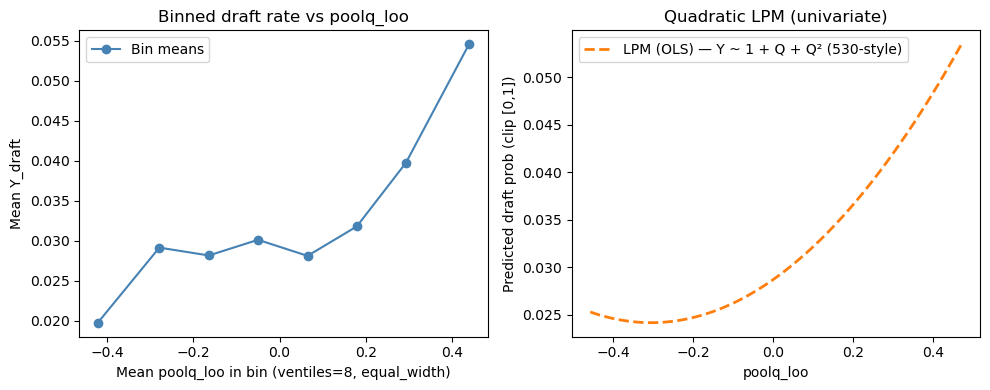

In [9]:
# CELL 4 — Tier 1 EDA · binned draft vs Q · quadratic LPM · controls (C, minutes)

if RUN_CELL4:
    if "df" not in globals():
        print("  CELL 4 skipped — df not defined; run CELL 2.")
    elif "CFG" not in globals():
        print("  CELL 4 skipped — CFG undefined; run CELL 1.")
    else:
        import numpy as np
        import matplotlib.pyplot as plt
        import pandas as pd

        from sports_pipeline.panel_build import assign_poolq_bin_labels, filter_panel
        from sports_pipeline.tier1_mechanism_vars import TIER1_CROWDING_COL, tier1_primary_pool_column

        if CELL4_MATCH_530_VENTILE:
            print(
                "CELL 4 — 530-style: filter_panel(CFG); bins on poolq_loo;",
                f"PERF_METRIC={PERF_METRIC!r}",
            )
            base = filter_panel(df, CFG)
            Qcol = "poolq_loo"
            Ccol_opt = TIER1_CROWDING_COL if TIER1_CROWDING_COL in base.columns else None
            req = ["poolq_loo", "Y_draft", "minutes"]
            miss = [c for c in req if c not in base.columns]
            if miss:
                print("  CELL 4 skipped — missing columns:", miss)
                use = None
            else:
                use = base.dropna(subset=req).copy()
        else:
            Qcol = tier1_primary_pool_column(PRIMARY_POOL_MODE)
            Ccol_opt = TIER1_CROWDING_COL
            need = {Qcol, Ccol_opt, "minutes", "Y_draft"}
            miss = sorted(need - set(df.columns))
            if miss:
                print("  CELL 4 skipped — missing columns:", miss)
                use = None
            else:
                use = df.dropna(subset=[Qcol, Ccol_opt, "Y_draft", "minutes"]).copy()
                mm = float(getattr(CFG, "min_minutes", 0.0))
                if mm > 0:
                    use = use.loc[pd.to_numeric(use["minutes"], errors="coerce") >= mm]

        if use is not None and len(use) > 0:
            print("CELL 4 modeling sample n =", len(use))
            show_cols = [c for c in ["perf", "poolq_loo", "congestion_quality", "congestion_crowding", "minutes", "Y_draft"] if c in use.columns]
            print(use[show_cols].describe())

            v = int(getattr(CFG, "ventiles", 20))
            pmode = str(getattr(CFG, "poolq_binning", "quantile")).strip().lower()
            work = use.assign(_bin=assign_poolq_bin_labels(use[Qcol], v, pmode))
            bt = (
                work.dropna(subset=["_bin"])
                .groupby("_bin", observed=True)
                .agg(
                    n=("Y_draft", "size"),
                    draft_rate=("Y_draft", "mean"),
                    q_mean=(Qcol, "mean"),
                )
                .reset_index()
                .sort_values("_bin")
            )
            print(bt.head(8).to_string(index=False))
            print("...")
            print(bt.tail(3).to_string(index=False))

            y = use["Y_draft"].astype(float).to_numpy()
            qv = use[Qcol].astype(float).to_numpy()
            q2 = qv**2
            m0 = np.isfinite(y) & np.isfinite(qv) & np.isfinite(q2)
            X1 = np.column_stack([np.ones(m0.sum()), qv[m0], q2[m0]])
            b1, *_ = np.linalg.lstsq(X1, y[m0], rcond=None)
            print("Y ~ 1 + Q + Q²  (LPM, univariate):", dict(zip(["const", "Q", "Q_sq"], b1)))

            mv = pd.to_numeric(use["minutes"], errors="coerce").astype(float).to_numpy()
            C_active = (
                Ccol_opt
                if (Ccol_opt is not None and Ccol_opt in use.columns and Ccol_opt != Qcol)
                else None
            )

            if CELL4_MATCH_530_VENTILE:
                grid = np.linspace(
                    np.nanpercentile(qv[m0], 5),
                    np.nanpercentile(qv[m0], 95),
                    80,
                )
                yhat = b1[0] + b1[1] * grid + b1[2] * grid**2
                yhat = np.clip(yhat, 0.0, 1.0)
                curve_label = "LPM (OLS) — Y ~ 1 + Q + Q² (530-style)"
                pd_title = "Quadratic LPM (univariate)"
            else:
                if C_active is None:
                    m1 = m0 & np.isfinite(mv)
                    X2 = np.column_stack([np.ones(m1.sum()), qv[m1], q2[m1], mv[m1]])
                    b2, *_ = np.linalg.lstsq(X2, y[m1], rcond=None)
                    labels = ["const", "Q", "Q_sq", "minutes"]
                    print("Y ~ 1 + Q + Q² + minutes:", dict(zip(labels, b2)))
                    med_min = float(np.nanmedian(mv[m1]))
                    grid = np.linspace(np.nanpercentile(qv[m1], 5), np.nanpercentile(qv[m1], 95), 80)
                    yhat = b2[0] + b2[1] * grid + b2[2] * grid**2 + b2[3] * med_min
                else:
                    cv = use[C_active].astype(float).to_numpy()
                    m1 = m0 & np.isfinite(cv) & np.isfinite(mv)
                    X2 = np.column_stack([np.ones(m1.sum()), qv[m1], q2[m1], cv[m1], mv[m1]])
                    b2, *_ = np.linalg.lstsq(X2, y[m1], rcond=None)
                    labels = ["const", "Q", "Q_sq", "C", "minutes"]
                    print("Y ~ 1 + Q + Q² + C + minutes:", dict(zip(labels, b2)))
                    c_med = float(np.nanmedian(cv[m1]))
                    med_min = float(np.nanmedian(mv[m1]))
                    grid = np.linspace(np.nanpercentile(qv[m1], 5), np.nanpercentile(qv[m1], 95), 80)
                    yhat = b2[0] + b2[1] * grid + b2[2] * grid**2 + b2[3] * c_med + b2[4] * med_min
                yhat = np.clip(yhat, 0.0, 1.0)
                curve_label = "LPM + controls @ median C, minutes"
                pd_title = "PD-style: Q grid, C & minutes fixed"

            _eda = str(globals().get("CELL4_EDA_PLOT_STYLE", "poolq_line")).strip().lower()
            if _eda not in ("poolq_line", "bins_bars_520"):
                _eda = "poolq_line"

            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            ax0, ax1 = axes
            if _eda == "bins_bars_520":
                _bin1 = bt["_bin"].astype(int) + 1
                ax0.bar(
                    _bin1,
                    bt["draft_rate"],
                    color="steelblue",
                    edgecolor="white",
                    linewidth=0.4,
                )
                ax0.set_xlabel(f"Ventile bin (1 = lowest {Qcol})")
                ax0.set_ylabel("Mean Y_draft")
                ax0.set_title(f"Mean draft rate by ventile of {Qcol}")
                ax0.set_xticks(_bin1)
                ax0.set_ylim(bottom=0)
                ax0.grid(True, axis="y", alpha=0.3)
            else:
                ax0.plot(bt["q_mean"], bt["draft_rate"], "o-", color="steelblue", label="Bin means")
                ax0.set_xlabel(f"Mean {Qcol} in bin (ventiles={v}, {pmode})")
                ax0.set_ylabel("Mean Y_draft")
                ax0.set_title(f"Binned draft rate vs {Qcol}")
                ax0.legend(loc="best")

            ax1.plot(grid, yhat, "--", color="C1", linewidth=2, label=curve_label)
            ax1.set_xlabel(Qcol)
            ax1.set_ylabel("Predicted draft prob (clip [0,1])")
            ax1.set_title(pd_title)
            ax1.legend(loc="best")
            fig.tight_layout()
            plt.show()
else:
    print("  CELL 4 skipped  (RUN_CELL4 = False in CELL 0)")
